# Najtańszy przepływ o zadanej wielkości oraz przepływ maksymalny
**Algorytm: Metoda kolejnych najkrótszych ścieżek (Successive Shortest Path) z algorytmem Bellmana-Forda**


Problem najtańszego przepływu (Min-Cost Flow) polega na przesłaniu określonej liczby jednostek przepływu ze źródła ($s$) do ujścia ($t$) w grafie skierowanym, tak aby zminimalizować całkowity koszt. Każda krawędź posiada przepustowość (maksymalną liczbę jednostek, jaka może przez nią przepłynąć) oraz koszt jednostkowy (koszt przesłania jednej jednostki).

Do rozwiązania tego problemu użyto **Metody kolejnych najkrótszych ścieżek (Successive Shortest Path)** połączonej z **Algorytmem Bellmana-Forda**. Kształt tego rozwiązania wynika z następujących założeń:

1.  Algorytm iteracyjnie szuka najtańszej ścieżki powiększającej ze źródła do ujścia. Po znalezieniu takiej ścieżki puszczany jest nią maksymalny możliwy przepływ (ograniczony przez najwęższe gardło ścieżki lub brakujący przepływ docelowy).
2. **Dlaczego Bellman-Ford?** Podczas przesyłania przepływu krawędzią skierowaną z $u$ do $v$, tworzymy tzw. "krawędź powrotną" (rezydualną) z $v$ do $u$ o przepustowości równej przesłanemu przepływowi. Koszt takiej krawędzi jest **ujemny** (wynosi $-c$, gdzie $c$ to oryginalny koszt). Ujemny koszt pozwala algorytmowi "wycofać" wcześniej przesłany przepływ, jeśli w późniejszych iteracjach znajdzie się lepsza, bardziej globalnie optymalna ścieżka. Standardowy algorytm Dijkstry nie radzi sobie z wagami ujemnymi, dlatego użycie algorytmu Bellmana-Forda (o złożoności $O(V \cdot E)$) jest w tym przypadku konieczne i w pełni uzasadnione.


## Wytłumaczony przykład działania

Wyobraźmy sobie prosty graf z 3 wierzchołkami: Źródło (0), Węzeł pośredni (1) i Ujście (2).
Mamy dwie ścieżki:
- Krawędź A: $0 \rightarrow 1$ (przepustowość: 2, koszt: 10)
- Krawędź B: $1 \rightarrow 2$ (przepustowość: 2, koszt: 10)
- Krawędź C (bezpośrednia): $0 \rightarrow 2$ (przepustowość: 1, koszt: 50)

Cel: Przesłać 2 jednostki przepływu najniższym kosztem.

**Iteracja 1:**
1. Bellman-Ford szuka najtańszej ścieżki z 0 do 2.
2. Ścieżka $0 \rightarrow 1 \rightarrow 2$ kosztuje 20 (10 + 10). Ścieżka $0 \rightarrow 2$ kosztuje 50.
3. Algorytm wybiera $0 \rightarrow 1 \rightarrow 2$. Wąskie gardło to 2. Puszczamy 2 jednostki przepływu.
4. Całkowity koszt rośnie o $2 \times 20 = 40$. Zapotrzebowanie zostało zaspokojone.
5. Graf rezydualny aktualizuje się: powstają ujemne krawędzie $2 \rightarrow 1$ (koszt -10) oraz $1 \rightarrow 0$ (koszt -10) o przepustowości 2.

**Co by było, gdybyśmy chcieli przesłać 3 jednostki?**
Iteracja 1 przesyła 2 jednostki kosztem 40. Zostaje 1 jednostka do przesłania.
**Iteracja 2:**
1. Bellman-Ford odpala się na grafie rezydualnym. Ścieżka $0 \rightarrow 1 \rightarrow 2$ nie ma już przepustowości "w przód".
2. Jedyna dostępna ścieżka to $0 \rightarrow 2$ (koszt 50).
3. Puszczamy 1 jednostkę tą ścieżką. Koszt rośnie o $1 \times 50 = 50$.
4. Sumaryczny koszt wynosi $40 + 50 = 90$, a łączny przepływ to 3.

In [11]:
class MinCostFlow:
    def __init__(self, n):
        self.n = n
        # Graf jako lista sąsiedztwa.
        # Każdy element to słownik przechowujący dane o krawędzi,
        # w tym wskaźnik na jej rezydualny odpowiednik.
        self.graph = {i: [] for i in range(n)}

    def add_edge(self, u, v, cap, cost):
        """Dodaje krawędź skierowaną oraz krawędź rezydualną."""
        forward_edge = {'v': v, 'cap': cap, 'flow': 0, 'cost': cost, 'rev': len(self.graph[v])}
        reverse_edge = {'v': u, 'cap': 0, 'flow': 0, 'cost': -cost, 'rev': len(self.graph[u])}

        self.graph[u].append(forward_edge)
        self.graph[v].append(reverse_edge)

    def bellman_ford(self, s, t):
        """
        Znajduje najtańszą ścieżkę w grafie ze źródła s do ujścia t.
        Zwraca: (ścieżka_jako_lista_krawędzi, minimalny_koszt) lub None, jeśli brak ścieżki.
        """
        dist = {i: float('inf') for i in range(self.n)}
        parent_node = {i: None for i in range(self.n)}
        parent_edge_idx = {i: None for i in range(self.n)}
        dist[s] = 0

        # Relaksacja krawędzi (V - 1) razy
        for _ in range(self.n - 1):
            updated = False
            for u in range(self.n):
                if dist[u] == float('inf'):
                    continue
                for idx, edge in enumerate(self.graph[u]):
                    v = edge['v']
                    residual_cap = edge['cap'] - edge['flow']
                    # Jeśli można przepchnąć przepływ i jest taniej
                    if residual_cap > 0 and dist[u] + edge['cost'] < dist[v]:
                        dist[v] = dist[u] + edge['cost']
                        parent_node[v] = u
                        parent_edge_idx[v] = idx
                        updated = True
            if not updated:
                break

        if dist[t] == float('inf'):
            return None, 0 # Brak ścieżki powiększającej

        # Odtworzenie ścieżki od t do s
        path = []
        curr = t
        while curr != s:
            p = parent_node[curr]
            idx = parent_edge_idx[curr]
            path.append((p, idx))
            curr = p

        path.reverse() # Odwracamy, by była od s do t
        return path, dist[t]

    def solve(self, s, t, required_flow=float('inf')):
        """
        Główna pętla algorytmu. Szuka przepływu do zadanej wielkości.
        Jeśli required_flow = inf, szuka przepływu maksymalnego.
        """
        total_flow = 0
        total_cost = 0

        while total_flow < required_flow:
            path, path_cost = self.bellman_ford(s, t)

            if not path:
                # Nie da się już puścić żadnego przepływu
                break

            # Znajdź "wąskie gardło" (bottleneck) na ścieżce
            bottleneck = float('inf')
            for u, idx in path:
                edge = self.graph[u][idx]
                residual_cap = edge['cap'] - edge['flow']
                bottleneck = min(bottleneck, residual_cap)

            # Upewnij się, że nie przekroczymy wymaganego przepływu
            push_flow = min(bottleneck, required_flow - total_flow)

            # Aktualizacja przepływów (puszczamy flow przez ścieżkę)
            for u, idx in path:
                # Krawędź "w przód"
                forward_edge = self.graph[u][idx]
                forward_edge['flow'] += push_flow

                # Krawędź "w tył" (rezydualna)
                v = forward_edge['v']
                rev_idx = forward_edge['rev']
                reverse_edge = self.graph[v][rev_idx]
                reverse_edge['flow'] -= push_flow

            total_flow += push_flow
            total_cost += push_flow * path_cost

        return total_flow, total_cost

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_flow(mcf_instance, title="Wizualizacja Przepływu"):
    """
    Funkcja pomocnicza do rysowania grafu.
    Wykorzystuje NetworkX wyłącznie do wygenerowania estetycznego obrazka.
    Etykiety na krawędziach pokazują: Przepływ/Przepustowość (Koszt)
    """
    G = nx.DiGraph()

    # Przenoszenie danych z naszej logiki do obiektu graficznego
    for u in mcf_instance.graph:
        for edge in mcf_instance.graph[u]:
            v = edge['v']
            cap = edge['cap']
            flow = edge['flow']
            cost = edge['cost']

            # Ignorujemy sztuczne krawędzie rezydualne na rysunku (te o pierwotnej przepustowości 0)
            if cap > 0:
                G.add_edge(u, v, weight=cost)
                G[u][v]['label'] = f"{flow}/{cap} (${cost})"
                G[u][v]['flow'] = flow

    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G, seed=42) # Ustalony seed dla powtarzalności układu

    # Rysowanie węzłów
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
    nx.draw_networkx_labels(G, pos, font_weight='bold')

    # Kolorowanie krawędzi: czerwone jeśli przez krawędź płynie jakikolwiek przepływ
    edge_colors = ['red' if G[u][v]['flow'] > 0 else 'gray' for u, v in G.edges()]
    edge_widths = [2.5 if G[u][v]['flow'] > 0 else 1.0 for u, v in G.edges()]

    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, arrowsize=20)

    # Etykiety
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, label_pos=0.3)

    plt.title(title)
    plt.axis('off')
    plt.show()

================== GRAF 1 ==================
Graf reprezentuje model dystrybucji: 0 to magazyn, 3 to docelowy sklep.

[Przykład 1] PRZEPŁYW MAKSYMALNY
Osiągnięty przepływ: 5
Całkowity koszt: 135


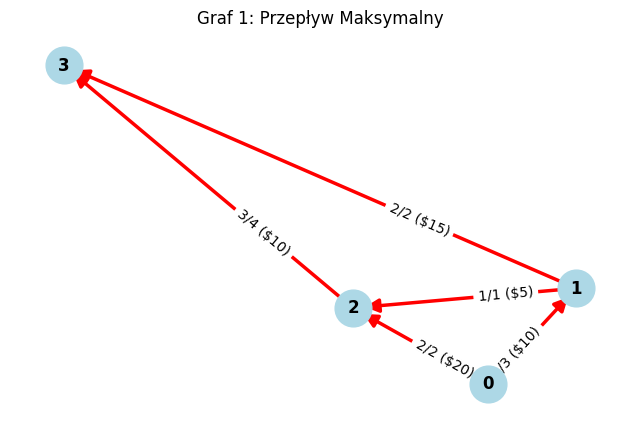


[Przykład 2] ZADANY PRZEPŁYW = 2
Osiągnięty przepływ: 2
Całkowity koszt: 50


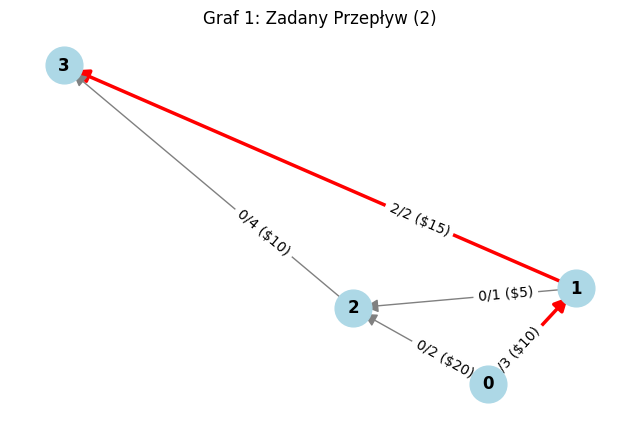

In [19]:
print("================== GRAF 1 ==================")
print("Graf reprezentuje model dystrybucji: 0 to magazyn, 3 to docelowy sklep.\n")

# Przykład 1: Maksymalny przepływ
mcf_max_1 = MinCostFlow(4)
mcf_max_1.add_edge(0, 1, 3, 10) # u, v, cap, cost
mcf_max_1.add_edge(0, 2, 2, 20)
mcf_max_1.add_edge(1, 2, 1, 5)
mcf_max_1.add_edge(1, 3, 2, 15)
mcf_max_1.add_edge(2, 3, 4, 10)

flow, cost = mcf_max_1.solve(0, 3)
print(f"[Przykład 1] PRZEPŁYW MAKSYMALNY")
print(f"Osiągnięty przepływ: {flow}")
print(f"Całkowity koszt: {cost}")
visualize_flow(mcf_max_1, "Graf 1: Przepływ Maksymalny")


# Przykład 2: Przepływ o zadanej wielkości (np. flow = 3)
mcf_target_1 = MinCostFlow(4)
mcf_target_1.add_edge(0, 1, 3, 10)
mcf_target_1.add_edge(0, 2, 2, 20)
mcf_target_1.add_edge(1, 2, 1, 5)
mcf_target_1.add_edge(1, 3, 2, 15)
mcf_target_1.add_edge(2, 3, 4, 10)

target_flow = 2
flow, cost = mcf_target_1.solve(0, 3, required_flow=target_flow)
print(f"\n[Przykład 2] ZADANY PRZEPŁYW = {target_flow}")
print(f"Osiągnięty przepływ: {flow}")
print(f"Całkowity koszt: {cost}")
visualize_flow(mcf_target_1, f"Graf 1: Zadany Przepływ ({target_flow})")

================== GRAF 2 ==================
Złożona sieć transportowa (węzły 0-5).

[Przykład 3] PRZEPŁYW MAKSYMALNY
Osiągnięty przepływ: 9
Całkowity koszt: 111


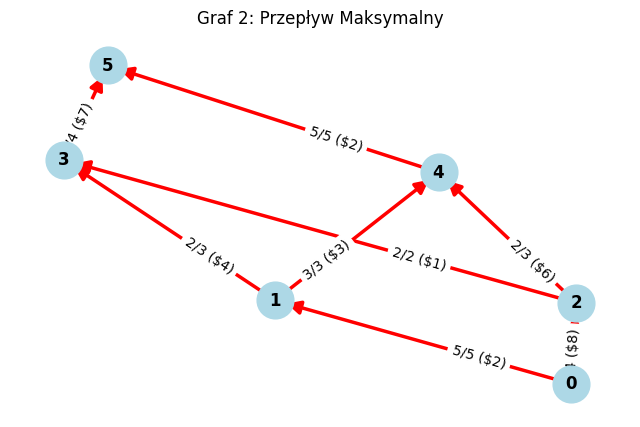


[Przykład 4] ZADANY PRZEPŁYW = 6
Osiągnięty przepływ: 6
Całkowity koszt: 63


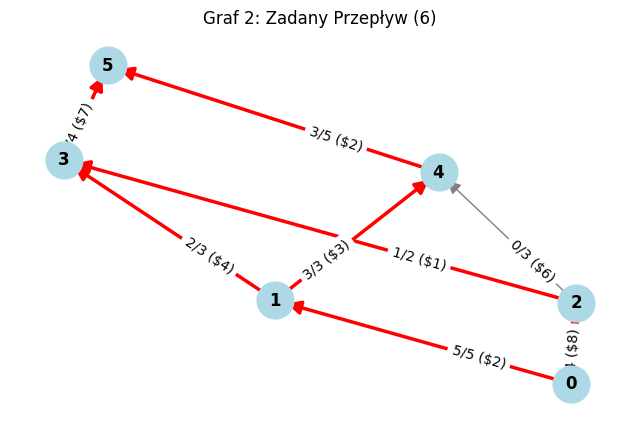

In [20]:
print("================== GRAF 2 ==================")
print("Złożona sieć transportowa (węzły 0-5).\n")

# Przykład 3: Maksymalny przepływ
mcf_max_2 = MinCostFlow(6)
mcf_max_2.add_edge(0, 1, 5, 2)
mcf_max_2.add_edge(0, 2, 4, 8)
mcf_max_2.add_edge(1, 3, 3, 4)
mcf_max_2.add_edge(1, 4, 3, 3)
mcf_max_2.add_edge(2, 3, 2, 1)
mcf_max_2.add_edge(2, 4, 3, 6)
mcf_max_2.add_edge(3, 5, 4, 7)
mcf_max_2.add_edge(4, 5, 5, 2)

flow, cost = mcf_max_2.solve(0, 5)
print(f"[Przykład 3] PRZEPŁYW MAKSYMALNY")
print(f"Osiągnięty przepływ: {flow}")
print(f"Całkowity koszt: {cost}")
visualize_flow(mcf_max_2, "Graf 2: Przepływ Maksymalny")


# Przykład 4: Przepływ o zadanej wielkości (np. flow = 6)
# Zauważ jak algorytm wybierze optymalną trasę unikając najdroższych ścieżek
mcf_target_2 = MinCostFlow(6)
mcf_target_2.add_edge(0, 1, 5, 2)
mcf_target_2.add_edge(0, 2, 4, 8)
mcf_target_2.add_edge(1, 3, 3, 4)
mcf_target_2.add_edge(1, 4, 3, 3)
mcf_target_2.add_edge(2, 3, 2, 1)
mcf_target_2.add_edge(2, 4, 3, 6)
mcf_target_2.add_edge(3, 5, 4, 7)
mcf_target_2.add_edge(4, 5, 5, 2)

target_flow_2 = 6
flow, cost = mcf_target_2.solve(0, 5, required_flow=target_flow_2)
print(f"\n[Przykład 4] ZADANY PRZEPŁYW = {target_flow_2}")
print(f"Osiągnięty przepływ: {flow}")
print(f"Całkowity koszt: {cost}")
visualize_flow(mcf_target_2, f"Graf 2: Zadany Przepływ ({target_flow_2})")

================== GRAF 3 (DUŻY GRAF - 20 WĘZŁÓW) ==================
Generowanie złożonej sieci transportowej z 20 węzłami (indeksy 0 do 19).
Węzeł 0 to źródło (s), węzeł 19 to ujście (t).

[Przykład 5] DUŻY GRAF - PRZEPŁYW MAKSYMALNY
Osiągnięty przepływ: 12
Całkowity koszt: 686


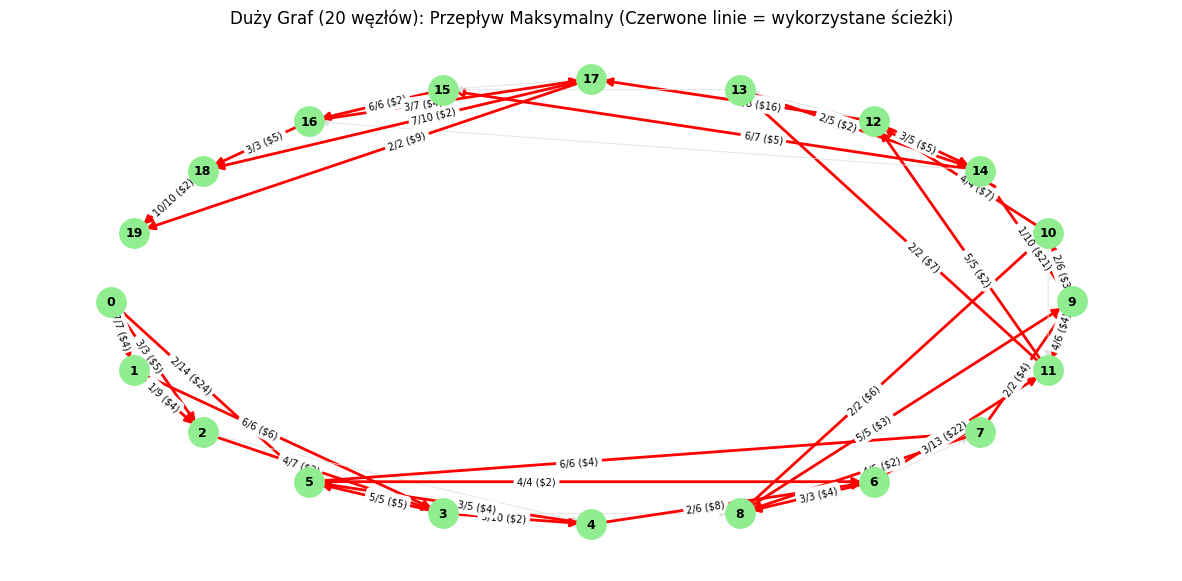


[Przykład 6] DUŻY GRAF - ZADANY PRZEPŁYW = 6
Osiągnięty przepływ: 6
Całkowity koszt: 317


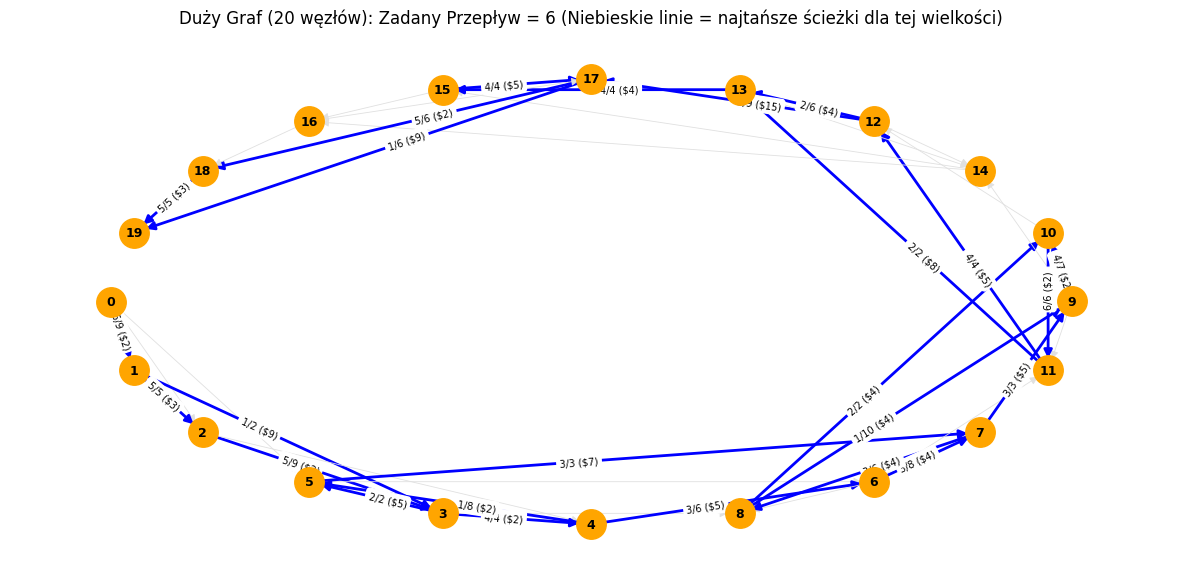

In [27]:
print("================== GRAF 3 (DUŻY GRAF - 20 WĘZŁÓW) ==================")
print("Generowanie złożonej sieci transportowej z 20 węzłami (indeksy 0 do 19).")
print("Węzeł 0 to źródło (s), węzeł 19 to ujście (t).\n")

import random
import networkx as nx
import matplotlib.pyplot as plt

# Ustalamy ziarno losowości (seed), aby sieć i wyniki były identyczne przy każdym uruchomieniu
random.seed(41)

# --- PRZYKŁAD 5: Przepływ maksymalny na dużym grafie ---
mcf_large_max = MinCostFlow(20)

# Automatyczne generowanie krawędzi w strukturze warstwowej, aby zasymulować dużą sieć
for i in range(19):
    # Podstawowa ścieżka (gwarantuje spójność sieci)
    cap1 = random.randint(4, 10)
    cost1 = random.randint(2, 5)
    mcf_large_max.add_edge(i, i + 1, cap1, cost1)

    # Skróty o krok dalej
    if i + 2 < 20:
        cap2 = random.randint(2, 6)
        cost2 = random.randint(4, 10)
        mcf_large_max.add_edge(i, i + 2, cap2, cost2)

    # Dalekie skróty o dużej przepustowości, ale bardzo drogie
    if i % 3 == 0 and i + 5 < 20:
        cap3 = random.randint(8, 15)
        cost3 = random.randint(15, 25)
        mcf_large_max.add_edge(i, i + 5, cap3, cost3)

flow_m, cost_m = mcf_large_max.solve(0, 19)
print(f"[Przykład 5] DUŻY GRAF - PRZEPŁYW MAKSYMALNY")
print(f"Osiągnięty przepływ: {flow_m}")
print(f"Całkowity koszt: {cost_m}")

# Budowanie i rysowanie grafu dla przepływu maksymalnego
plt.figure(figsize=(15, 7))
G_max = nx.DiGraph()
for u in mcf_large_max.graph:
    for edge in mcf_large_max.graph[u]:
        v, cap, flow, cost = edge['v'], edge['cap'], edge['flow'], edge['cost']
        if cap > 0: # Ignorujemy krawędzie rezydualne
            G_max.add_edge(u, v, label=f"{flow}/{cap} (${cost})", flow=flow)

# Układ shell_layout (dwie pętle) ładnie organizuje 20 węzłów bez chaosu wizualnego
pos_large = nx.shell_layout(G_max)
nx.draw_networkx_nodes(G_max, pos_large, node_size=450, node_color='lightgreen')
nx.draw_networkx_labels(G_max, pos_large, font_size=9, font_weight='bold')

edge_colors_m = ['red' if G_max[u][v]['flow'] > 0 else '#E0E0E0' for u, v in G_max.edges()]
edge_widths_m = [2.0 if G_max[u][v]['flow'] > 0 else 0.6 for u, v in G_max.edges()]
nx.draw_networkx_edges(G_max, pos_large, edge_color=edge_colors_m, width=edge_widths_m, arrowsize=12)

# Filtrowanie etykiet krawędzi - pokazujemy opisy tylko dla krawędzi, którymi płynie prąd (dla czytelności)
active_labels_m = {(u, v): d['label'] for u, v, d in G_max.edges(data=True) if d['flow'] > 0}
nx.draw_networkx_edge_labels(G_max, pos_large, edge_labels=active_labels_m, font_size=7, label_pos=0.4)

plt.title("Duży Graf (20 węzłów): Przepływ Maksymalny (Czerwone linie = wykorzystane ścieżki)")
plt.axis('off')
plt.show()


# --- PRZYKŁAD 6: Przepływ o zadanej wielkości na tym samym dużym grafie ---
mcf_large_tgt = MinCostFlow(20)
random.seed(42) # Ponowne ustawienie seed, aby wygenerować dokładnie ten sam graf

for i in range(19):
    cap1, cost1 = random.randint(4, 10), random.randint(2, 5)
    mcf_large_tgt.add_edge(i, i + 1, cap1, cost1)
    if i + 2 < 20:
        cap2, cost2 = random.randint(2, 6), random.randint(4, 10)
        mcf_large_tgt.add_edge(i, i + 2, cap2, cost2)
    if i % 3 == 0 and i + 5 < 20:
        cap3, cost3 = random.randint(8, 15), random.randint(15, 25)
        mcf_large_tgt.add_edge(i, i + 5, cap3, cost3)

target_flow_large = 6
flow_t, cost_t = mcf_large_tgt.solve(0, 19, required_flow=target_flow_large)
print(f"\n[Przykład 6] DUŻY GRAF - ZADANY PRZEPŁYW = {target_flow_large}")
print(f"Osiągnięty przepływ: {flow_t}")
print(f"Całkowity koszt: {cost_t}")

# Budowanie i rysowanie grafu dla zadanego przepływu
plt.figure(figsize=(15, 7))
G_tgt = nx.DiGraph()
for u in mcf_large_tgt.graph:
    for edge in mcf_large_tgt.graph[u]:
        v, cap, flow, cost = edge['v'], edge['cap'], edge['flow'], edge['cost']
        if cap > 0:
            G_tgt.add_edge(u, v, label=f"{flow}/{cap} (${cost})", flow=flow)

nx.draw_networkx_nodes(G_tgt, pos_large, node_size=450, node_color='orange')
nx.draw_networkx_labels(G_tgt, pos_large, font_size=9, font_weight='bold')

edge_colors_t = ['blue' if G_tgt[u][v]['flow'] > 0 else '#E0E0E0' for u, v in G_tgt.edges()]
edge_widths_t = [2.0 if G_tgt[u][v]['flow'] > 0 else 0.6 for u, v in G_tgt.edges()]
nx.draw_networkx_edges(G_tgt, pos_large, edge_color=edge_colors_t, width=edge_widths_t, arrowsize=12)

active_labels_t = {(u, v): d['label'] for u, v, d in G_tgt.edges(data=True) if d['flow'] > 0}
nx.draw_networkx_edge_labels(G_tgt, pos_large, edge_labels=active_labels_t, font_size=7, label_pos=0.4)

plt.title(f"Duży Graf (20 węzłów): Zadany Przepływ = {target_flow_large} (Niebieskie linie = najtańsze ścieżki dla tej wielkości)")
plt.axis('off')
plt.show()